In [1]:
# PFE Renault Tanger — IA Explicable
## Notebook 04 : SHAP — Pourquoi le modèle prédit cette valeur ?
### Objectif : expliquer chaque prédiction en langage clair

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
print("Librairies chargées ✓")

Librairies chargées ✓


In [3]:
# Charger le modèle XGBoost sauvegardé
model_xgb = joblib.load("../models/model_xgboost.pkl")

# Charger le dataset
df = pd.read_csv("../outputs/dataset_eau_propre.csv", parse_dates=['Date'])
df_prod = df[(df['TCM'] >= 100) & (df['is_weekend'] == 0)].copy().reset_index(drop=True)

FEATURES = [
    'TCM', 'ED_Total', 'EOR_Total', 'EI_Looker', 'EP_Looker',
    'jour_semaine', 'mois', 'trimestre', 'is_lundi',
    'ratio_EOR_ED', 'taux_EP', 'taux_EI'
]

df_xgb = df_prod[FEATURES + ['KPI_m3_veh', 'Date']].dropna().copy()
X = df_xgb[FEATURES]

print(f"Données chargées : {len(X)} jours")
print(f"Modèle XGBoost   : {model_xgb.n_estimators} arbres")

Données chargées : 65 jours
Modèle XGBoost   : 100 arbres


In [4]:
# SHAP TreeExplainer : optimisé pour XGBoost
# Principe : pour chaque prédiction, SHAP calcule la contribution
# de chaque variable (positive ou négative) au résultat final

explainer   = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X)

print("Valeurs SHAP calculées ✓")
print(f"Shape : {shap_values.shape}  ({len(X)} jours × {len(FEATURES)} features)")
print()
print("Interprétation :")
print("  Valeur SHAP > 0  →  cette variable AUGMENTE le KPI (mauvais)")
print("  Valeur SHAP < 0  →  cette variable DIMINUE le KPI  (bon)")
print("  Valeur SHAP = 0  →  pas d'impact")

Valeurs SHAP calculées ✓
Shape : (65, 12)  (65 jours × 12 features)

Interprétation :
  Valeur SHAP > 0  →  cette variable AUGMENTE le KPI (mauvais)
  Valeur SHAP < 0  →  cette variable DIMINUE le KPI  (bon)
  Valeur SHAP = 0  →  pas d'impact


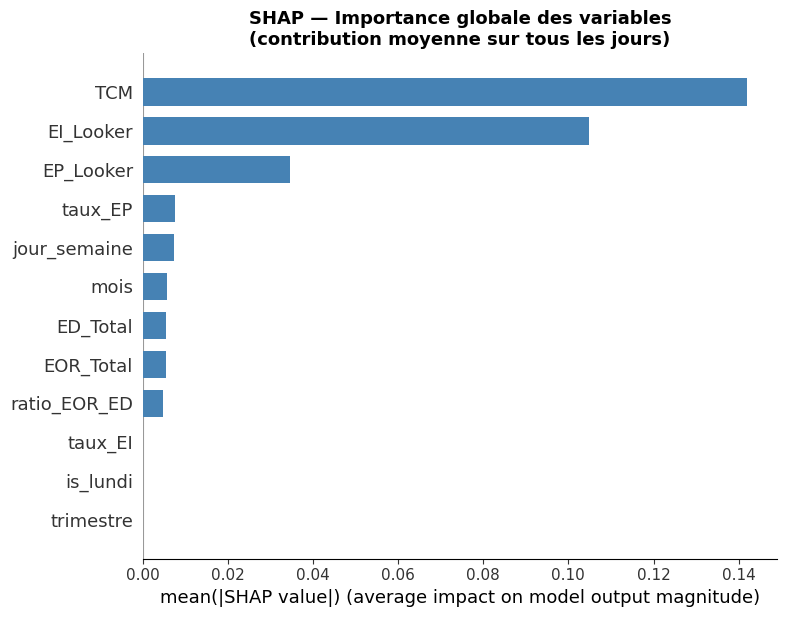

Graphique sauvegardé ✓


In [5]:
plt.figure(figsize=(12, 7))

shap.summary_plot(
    shap_values,
    X,
    plot_type="bar",
    feature_names=FEATURES,
    show=False,
    color='steelblue'
)

plt.title("SHAP — Importance globale des variables\n(contribution moyenne sur tous les jours)",
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/shap_importance_globale.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé ✓")

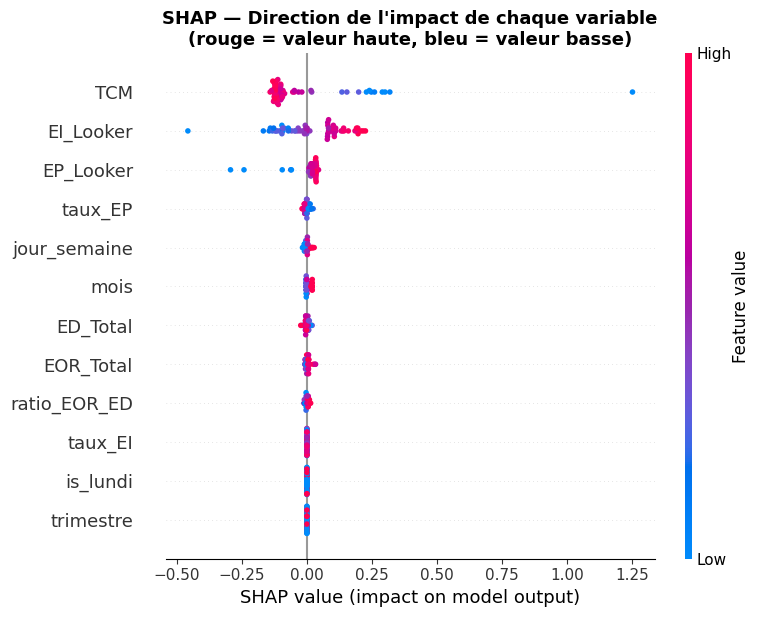

Graphique sauvegardé ✓


In [6]:
plt.figure(figsize=(12, 7))

shap.summary_plot(
    shap_values,
    X,
    feature_names=FEATURES,
    show=False
)

plt.title("SHAP — Direction de l'impact de chaque variable\n(rouge = valeur haute, bleu = valeur basse)",
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé ✓")

Explication pour le : 2026-04-22
KPI réel             : 1.076 m³/véh
KPI prédit           : 1.046 m³/véh



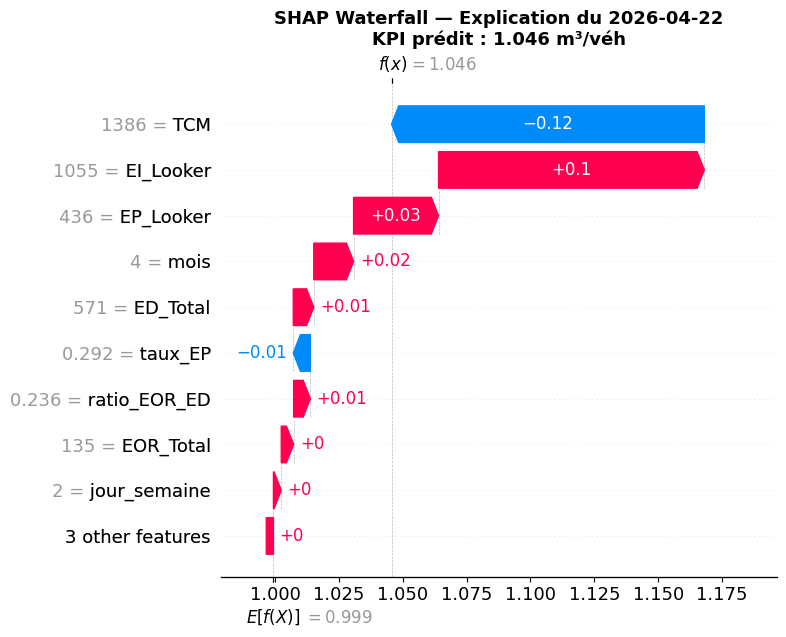

In [7]:
# Choisir le dernier jour disponible (22 avril 2026)
idx_jour = len(X) - 1
date_jour = df_xgb['Date'].iloc[idx_jour].date()
kpi_reel  = df_xgb['KPI_m3_veh'].iloc[idx_jour]
kpi_predit = model_xgb.predict(X.iloc[[idx_jour]])[0]

print(f"Explication pour le : {date_jour}")
print(f"KPI réel             : {kpi_reel:.3f} m³/véh")
print(f"KPI prédit           : {kpi_predit:.3f} m³/véh")
print()

# Waterfall plot = explication visuelle détaillée d'UN jour
shap_explanation = shap.Explanation(
    values=shap_values[idx_jour],
    base_values=explainer.expected_value,
    data=X.iloc[idx_jour].values,
    feature_names=FEATURES
)

plt.figure(figsize=(12, 6))
shap.plots.waterfall(shap_explanation, show=False)
plt.title(f"SHAP Waterfall — Explication du {date_jour}\nKPI prédit : {kpi_predit:.3f} m³/véh",
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/shap_waterfall_dernier_jour.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Cette fonction sera utilisée dans le système d'alertes (notebook 05)
# Elle traduit les valeurs SHAP en phrase compréhensible

def generer_explication_shap(idx, df_xgb, shap_values, model_xgb, seuil=1.25):
    """
    Génère une explication en français pour une prédiction donnée.
    Utilisée dans les alertes email et le dashboard Looker.
    """
    date     = df_xgb['Date'].iloc[idx].date()
    kpi_reel = df_xgb['KPI_m3_veh'].iloc[idx]
    kpi_pred = model_xgb.predict(X.iloc[[idx]])[0]

    # Top 3 features qui ont le plus contribué (en valeur absolue)
    contribs = pd.Series(shap_values[idx], index=FEATURES)
    top3_pos = contribs[contribs > 0].nlargest(3)   # augmentent le KPI
    top3_neg = contribs[contribs < 0].nsmallest(3)  # diminuent le KPI

    # Noms lisibles des features
    noms_lisibles = {
        'TCM'          : 'nombre de véhicules produits',
        'ED_Total'     : 'consommation eau déminéralisée',
        'EOR_Total'    : 'eau osmosée recyclée',
        'EI_Looker'    : 'eau industrielle totale',
        'EP_Looker'    : 'eau potable',
        'jour_semaine' : 'jour de la semaine',
        'mois'         : 'mois de l\'année',
        'trimestre'    : 'trimestre',
        'is_lundi'     : 'effet lundi (reprise)',
        'ratio_EOR_ED' : 'taux de recyclage EOR/ED',
        'taux_EP'      : 'part eau potable',
        'taux_EI'      : 'part eau industrielle'
    }

    # Construire le message
    statut = "⚠️ ANOMALIE" if kpi_pred > seuil * 1.15 else "✅ NORMAL"

    message = f"""
╔══════════════════════════════════════════════════╗
  RAPPORT IA — {date}  |  {statut}
╚══════════════════════════════════════════════════╝

  KPI prédit   : {kpi_pred:.3f} m³/véhicule
  KPI réel     : {kpi_reel:.3f} m³/véhicule
  Objectif     : {seuil:.2f} m³/véhicule

  FACTEURS QUI AUGMENTENT LE KPI (négatif) :"""

    for feat, val in top3_pos.items():
        nom = noms_lisibles.get(feat, feat)
        valeur_reelle = X.iloc[idx][feat]
        message += f"\n    → {nom} : {valeur_reelle:.1f}  (+{val:.3f} sur le KPI)"

    message += "\n\n  FACTEURS QUI RÉDUISENT LE KPI (positif) :"
    for feat, val in top3_neg.items():
        nom = noms_lisibles.get(feat, feat)
        valeur_reelle = X.iloc[idx][feat]
        message += f"\n    → {nom} : {valeur_reelle:.1f}  ({val:.3f} sur le KPI)"

    return message


# Test sur le dernier jour
print(generer_explication_shap(len(X)-1, df_xgb, shap_values, model_xgb))


╔══════════════════════════════════════════════════╗
  RAPPORT IA — 2026-04-22  |  ✅ NORMAL
╚══════════════════════════════════════════════════╝

  KPI prédit   : 1.046 m³/véhicule
  KPI réel     : 1.076 m³/véhicule
  Objectif     : 1.25 m³/véhicule

  FACTEURS QUI AUGMENTENT LE KPI (négatif) :
    → eau industrielle totale : 1055.0  (+0.104 sur le KPI)
    → eau potable : 436.0  (+0.033 sur le KPI)
    → mois de l'année : 4.0  (+0.016 sur le KPI)

  FACTEURS QUI RÉDUISENT LE KPI (positif) :
    → nombre de véhicules produits : 1386.0  (-0.122 sur le KPI)
    → part eau potable : 0.3  (-0.007 sur le KPI)


In [9]:
# Afficher l'explication pour les jours anomalies confirmés
dates_anomalies = ['2026-03-29', '2026-04-05']

for date_str in dates_anomalies:
    idx = df_xgb[df_xgb['Date'] == date_str].index
    if len(idx) > 0:
        print(generer_explication_shap(idx[0], df_xgb, shap_values, model_xgb))
        print()